In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# ==========================
# 1. Load dữ liệu
# ==========================
PROJECT = Path.cwd().parents[1]
PROC_TOMTOM = PROJECT / "data" / "processed" / "tomtom_stats_frc5"
PROC_PARQUET_PATH = PROC_TOMTOM / "traffic_clean.parquet"

print("Đang load:", PROC_PARQUET_PATH)
df = pd.read_parquet(PROC_PARQUET_PATH)
df.columns = df.columns.astype(str)
print("traffic_clean shape:", df.shape)
print("Một vài cột đầu:", df.columns[:5])


# ==========================
# 2. Tạo time_set_id với cửa sổ = 24
#    (0..23 lặp lại theo thứ tự thời gian)
# ==========================
WINDOW = 24

N = len(df)
trim_N = (N // WINDOW) * WINDOW  # cắt bớt phần dư nếu không chia hết cho 24
if trim_N != N:
    print(f"[WARN] Số dòng ({N}) không chia hết cho {WINDOW}, cắt xuống còn {trim_N}")
    df = df.iloc[:trim_N]

# tạo time_set_id = 0..23 lặp lại theo thứ tự
time_set_id = pd.Series(
    np.arange(len(df)) % WINDOW,
    index=df.index,
    name="time_set_id"
)

print("Số dòng sau khi cắt:", len(df))
print("Các giá trị time_set_id:", time_set_id.unique())


# ==========================
# 3. Phân bố vận tốc của một vài tuyến đường theo time_set_id
#    → vẽ trung bình theo từng time_set_id (0..23)
# ==========================

# chọn vài segment để vẽ (vd: 3 tuyến đầu tiên)
segments_to_plot = list(df.columns[:3])
print("Các tuyến sẽ vẽ:", segments_to_plot)

# gộp df và time_set_id vào 1 DataFrame tạm
df_long = df.copy()
df_long["time_set_id"] = time_set_id

plt.figure(figsize=(12, 6))

for seg in segments_to_plot:
    # mean theo từng time_set_id
    mean_by_slot = df_long.groupby("time_set_id")[seg].mean()
    plt.plot(mean_by_slot.index, mean_by_slot.values, marker="o", label=str(seg))

plt.xticks(range(WINDOW))
plt.xlabel("time_set_id (0..23)")
plt.ylabel("Giá trị (vận tốc đã tiền xử lý / z-score)")
plt.title("Phân bố vận tốc trung bình theo time_set_id\n(một vài tuyến đường)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ==========================
# 4. Phân bố vận tốc của TẤT CẢ tuyến đường
#    tại một time_set bất kỳ (histogram)
# ==========================

# bạn có thể đổi time_set_target tuỳ ý (0..23)
time_set_target = 10  # ví dụ: slot 10

mask_t = (time_set_id == time_set_target)
# lấy tất cả giá trị của mọi segment tại các dòng có time_set_id = time_set_target
values_t = df.loc[mask_t].values.ravel()
values_t = values_t[~np.isnan(values_t)]

plt.figure(figsize=(10, 4))
plt.hist(values_t, bins=40)
plt.xlabel("Giá trị (vận tốc/z-score)")
plt.ylabel("Số lượng (segment × ngày)")
plt.title(f"Phân bố vận tốc của tất cả tuyến đường tại time_set_id = {time_set_target}")
plt.tight_layout()
plt.show()


# ==========================
# 5. Phân bố vận tốc tại time_set + 1
#    để so sánh (histogram tương tự)
# ==========================

time_set_next = (time_set_target + 1) % WINDOW

mask_next = (time_set_id == time_set_next)
values_next = df.loc[mask_next].values.ravel()
values_next = values_next[~np.isnan(values_next)]

plt.figure(figsize=(10, 4))
plt.hist(values_next, bins=40)
plt.xlabel("Giá trị (vận tốc/z-score)")
plt.ylabel("Số lượng (segment × ngày)")
plt.title(f"Phân bố vận tốc của tất cả tuyến đường tại time_set_id = {time_set_next}")
plt.tight_layout()
plt.show()


Đang load: C:\AI\Specialized_Project2_github\Urban-Traffic-Links\data\processed\tomtom_stats_frc5\traffic_clean.parquet
traffic_clean shape: (528, 10459)
Một vài cột đầu: Index(['date', 'time_set_id', 'time_of_day_minutes', 'day_of_week',
       '-17040035685565'],
      dtype='object')
Số dòng sau khi cắt: 528
Các giá trị time_set_id: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Các tuyến sẽ vẽ: ['date', 'time_set_id', 'time_of_day_minutes']


TypeError: agg function failed [how->mean,dtype->object]

<Figure size 1200x600 with 0 Axes>

In [68]:
 # ======================================================
# CELL 0 — CHUẨN BỊ BIẾN segment, adj, neighbors
# ======================================================

from collections import defaultdict
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- CHỌN MỘT SEGMENT ĐỂ VẼ ---
segment = "-17040019559514"   # bạn có thể đổi segment tại đây

# --- LOAD EDGES và TẠO ADJACENCY LIST ---
EDGES = PROJECT / "data" / "raw" / "tomtom_stats_frc5" / "graphs" / "edges.csv"

edges = pd.read_csv(
    EDGES,
    dtype={"segment_u": str, "segment_v": str}
)

adj = defaultdict(set)
for _, row in edges.iterrows():
    u = row["segment_u"]
    v = row["segment_v"]
    adj[u].add(v)
    adj[v].add(u)

# --- TÌM NEIGHBORS ---
neighbors_raw = adj.get(str(segment), set())
neighbors = [n for n in neighbors_raw if n in df.columns]

print("Segment trung tâm:", segment)
print("Neighbors:", neighbors)
print("Số hàng xóm hợp lệ:", len(neighbors))


Segment trung tâm: -17040019559514
Neighbors: ['-17040020383919', '-17040023538588', '17040023538588', '17040020383919', '17040019559514', '17040018849149', '-17040018849149', '17040019408166', '-17040019408166', '17040020932175', '-17040020932175']
Số hàng xóm hợp lệ: 11


Đang vẽ các tuyến: ['-17040019559514', '-17040020383919', '-17040023538588', '17040023538588', '17040020383919', '17040019559514', '17040018849149', '-17040018849149', '17040019408166', '-17040019408166', '17040020932175', '-17040020932175']


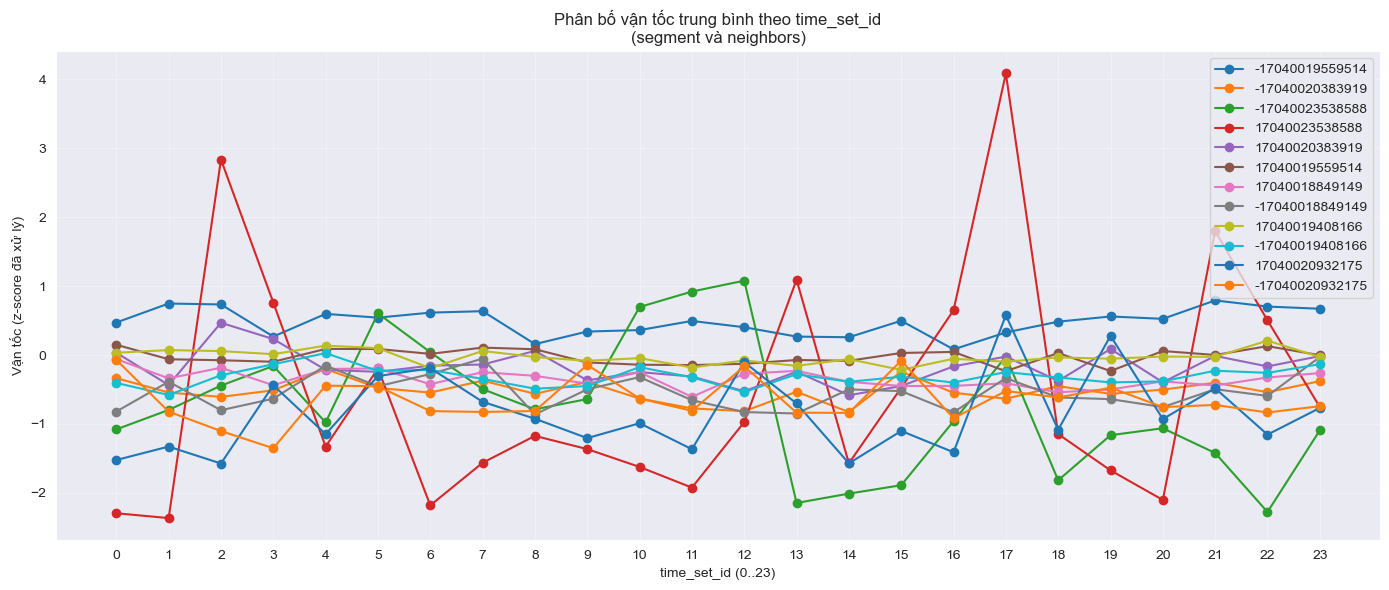

In [69]:
# ======================================================
# 6. VẼ biểu đồ phân bố vận tốc segment và neighbors
#    theo time_set_id (giống ảnh bạn yêu cầu)
# ======================================================

# Kiểm tra xem segment có tồn tại trong df hay không
if segment not in df.columns:
    print(f"Segment {segment} không tồn tại trong traffic_clean.")
else:
    # Chuẩn bị time_set_id (0..23)
    WINDOW = 24
    N = len(df)
    trim_N = (N // WINDOW) * WINDOW
    df_plot = df.iloc[:trim_N].copy()

    time_set_id = pd.Series(
        np.arange(len(df_plot)) % WINDOW,
        index=df_plot.index,
        name="time_set_id"
    )

    df_plot["time_set_id"] = time_set_id

    # Danh sách bao gồm segment chính + hàng xóm
    seg_list = [segment] + neighbors

    print("Đang vẽ các tuyến:", seg_list)

    plt.figure(figsize=(14, 6))

    for seg in seg_list:
        mean_by_slot = df_plot.groupby("time_set_id")[seg].mean()

        plt.plot(
            mean_by_slot.index,
            mean_by_slot.values,
            marker="o",
            label=str(seg)
        )

    plt.xticks(range(WINDOW))
    plt.xlabel("time_set_id (0..23)")
    plt.ylabel("Vận tốc (z-score đã xử lý)")
    plt.title("Phân bố vận tốc trung bình theo time_set_id\n(segment và neighbors)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


10 segment được chọn: ['17040019799094', '17040020037785', '-17040021935102', '-17040018893898', '-17040018803194', '17040035606995', '-17040018881738', '-17040020243037', '-17040022616444', '17040018959508']


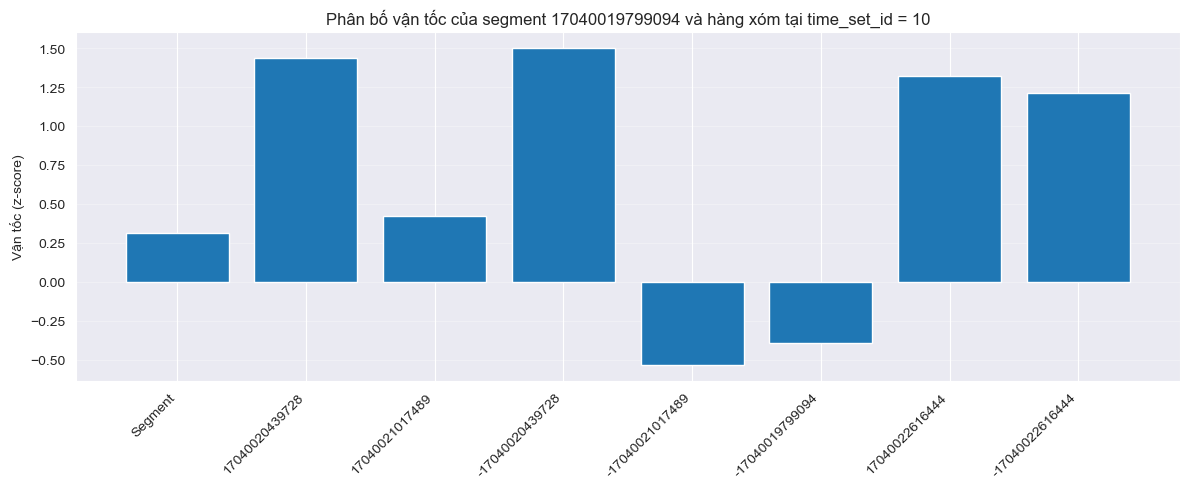

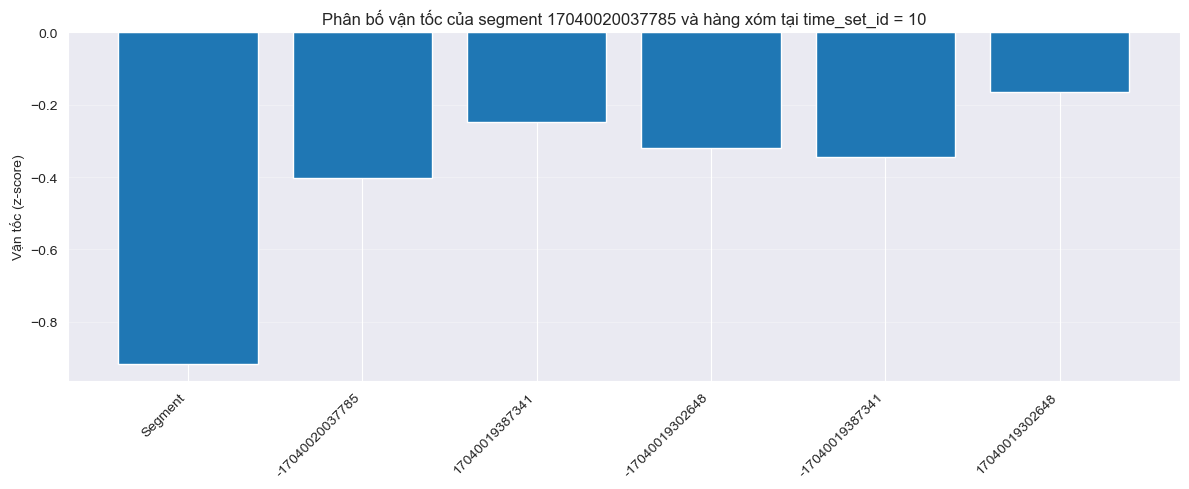

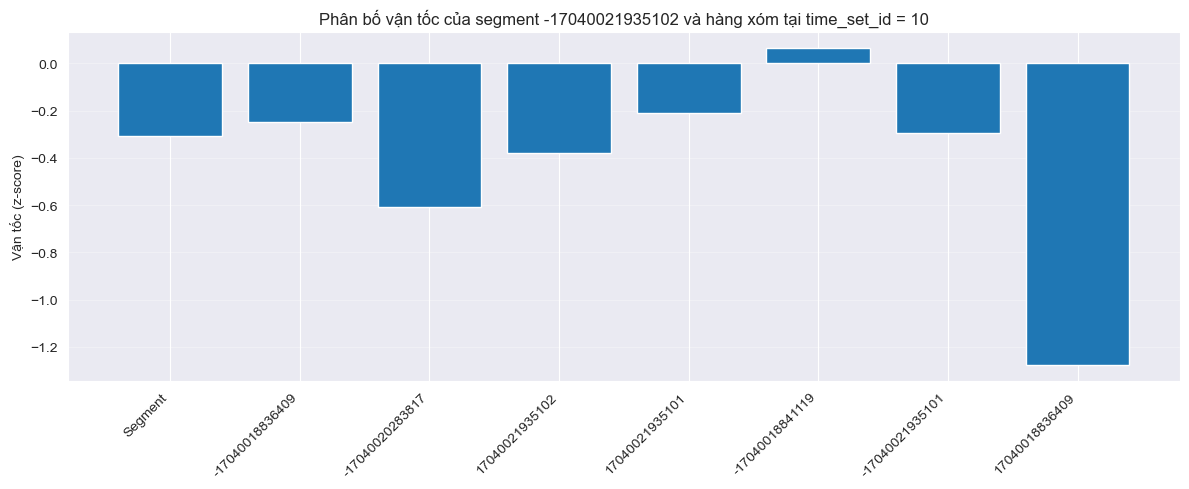

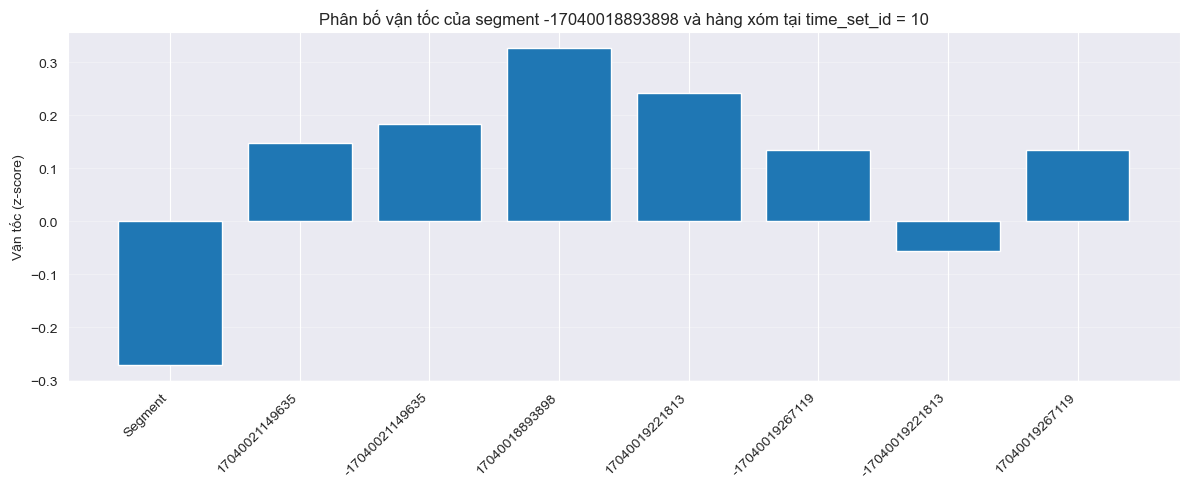

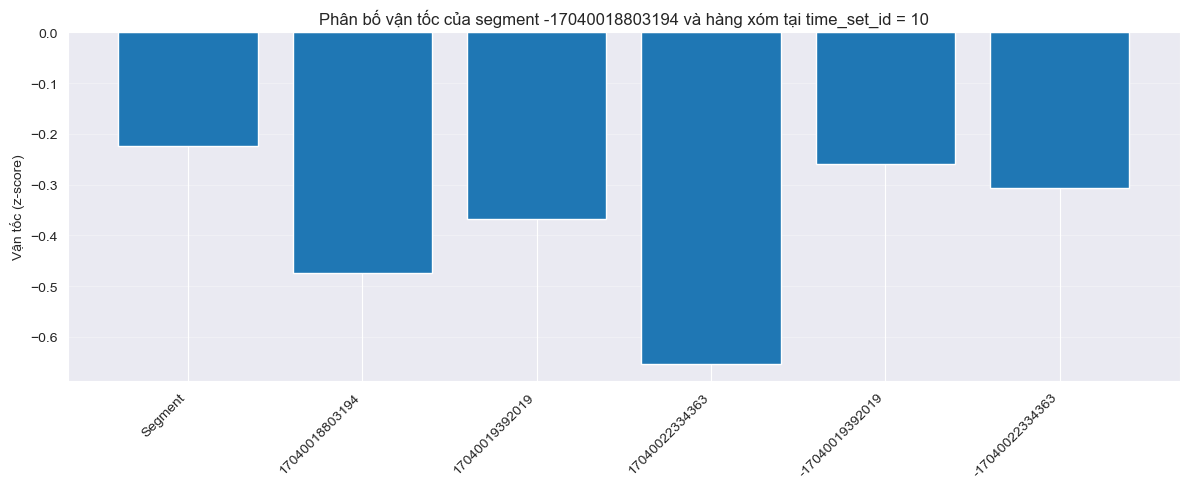

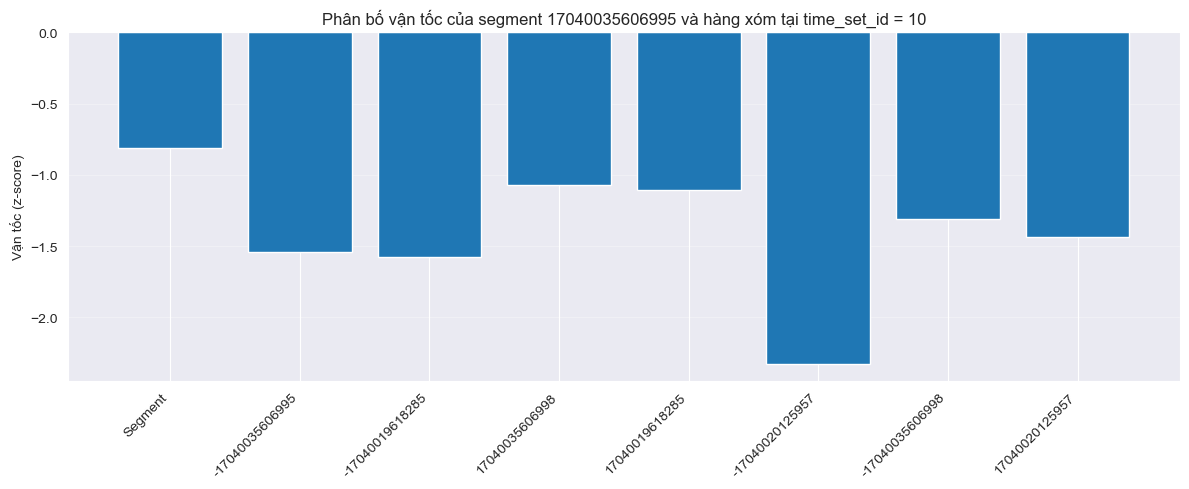

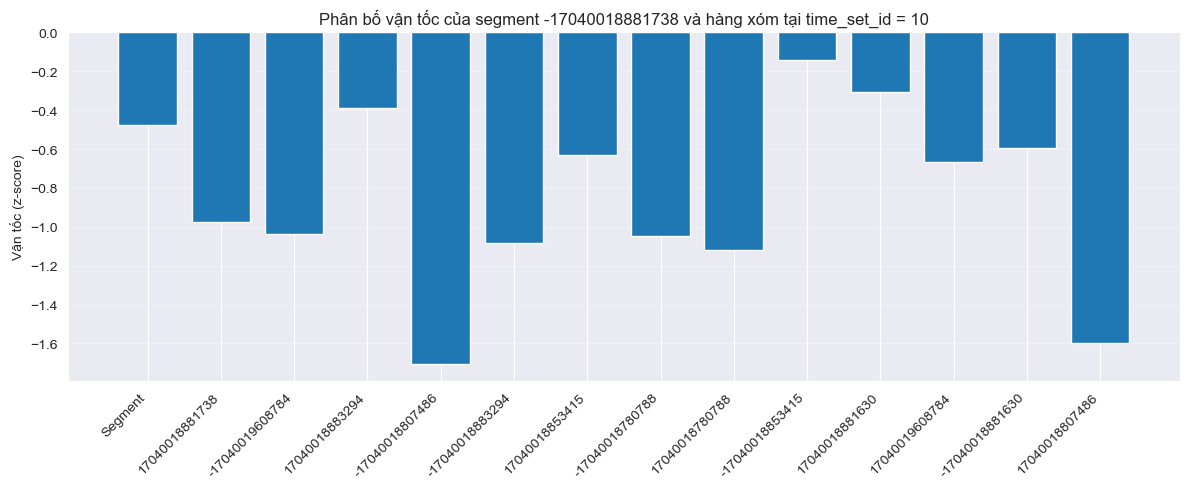

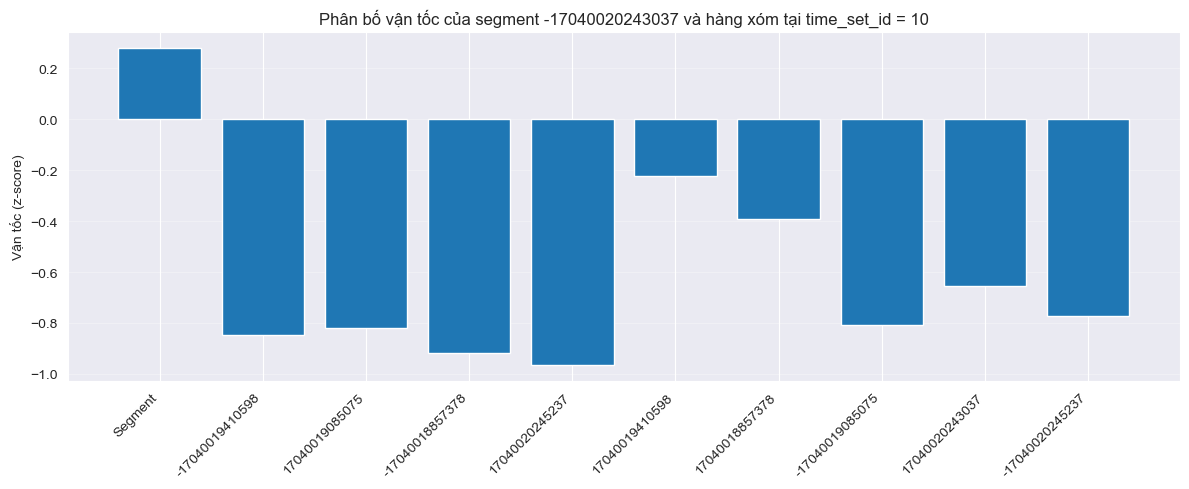

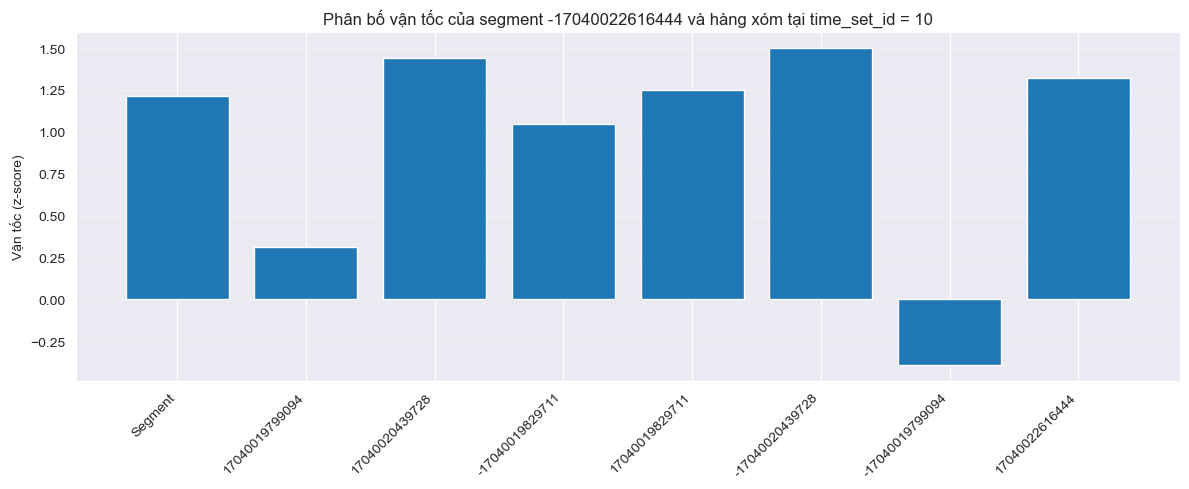

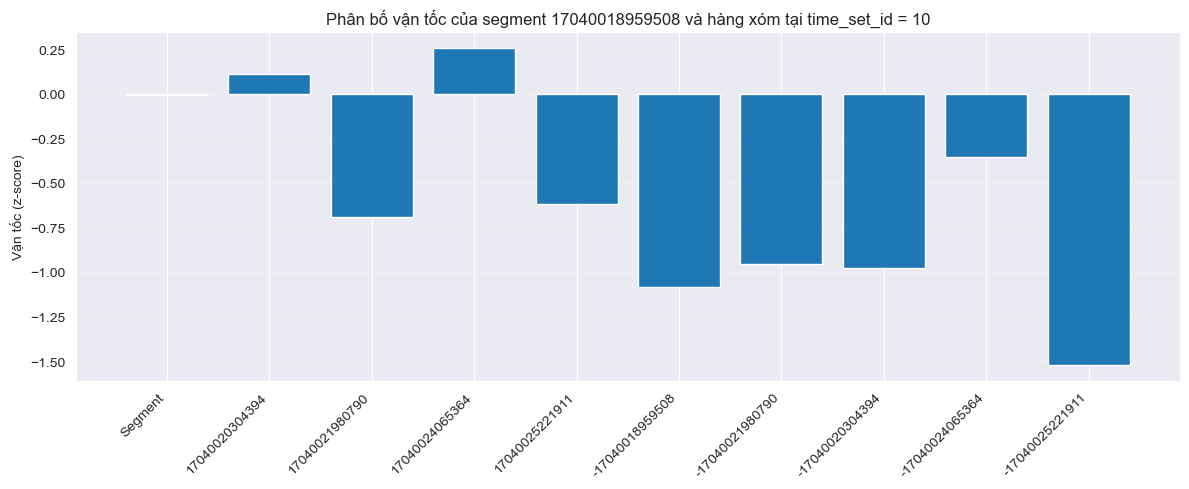

In [70]:
# ============================================================
# 7. VẼ RAW TIMELINE (KHÔNG AVERAGE): vận tốc của segment và neighbors
#    qua toàn bộ các time_set_id theo từng ngày
# ============================================================

import random

WINDOW = 24
N = len(df)
trim_N = (N // WINDOW) * WINDOW
df_raw = df.iloc[:trim_N].copy()

df_raw["time_set_id"] = np.arange(len(df_raw)) % WINDOW
df_raw["day_index"] = np.arange(len(df_raw)) // WINDOW  # để phân biệt từng ngày

# ------------------------------------------------------------
# Chọn 10 segment bất kỳ để đánh giá
# ------------------------------------------------------------
all_segments = list(df.columns)
random_segments = random.sample(all_segments, 10)

print("10 segment được chọn:", random_segments)

# ------------------------------------------------------------
# Hàm vẽ raw timeline cho từng segment
# ------------------------------------------------------------
def plot_segment_neighbors_bar(segment_id: str, slot: int):
    """
    Vẽ bar chart vận tốc (z-score) của 1 segment và hàng xóm của nó
    tại 1 time_set_id (slot) cụ thể.

    segment_id: id segment dạng string, ví dụ "-17040019559514"
    slot      : time_set_id (0..23)
    """
    # kiểm tra tồn tại trong df
    if segment_id not in df.columns:
        print(f"⚠️ Segment {segment_id} không tồn tại trong traffic_clean.")
        return

    # lấy hàng xóm từ adj rồi lọc những node có mặt trong df
    neighbors_raw = adj.get(segment_id, set())
    neighbors = [n for n in neighbors_raw if n in df.columns]

    if not neighbors:
        print("Segment này không có hàng xóm (hoặc hàng xóm không nằm trong df).")
        return

    # lấy giá trị tại time_set_id = slot
    target_value = df.iloc[slot][segment_id]
    neighbor_values = df.iloc[slot][neighbors]

    labels = ["Segment"] + neighbors
    values = [target_value] + list(neighbor_values.values)

    # vẽ bar
    plt.figure(figsize=(12, 5))
    plt.bar(labels, values)

    plt.title(
        f"Phân bố vận tốc của segment {segment_id} và hàng xóm "
        f"tại time_set_id = {slot}"
    )
    plt.ylabel("Vận tốc (z-score)")
    plt.xticks(rotation=45, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Vẽ cho 10 segment đã chọn
# ------------------------------------------------------------
for seg in random_segments:
    plot_segment_neighbors_bar(seg,10)
